In [1]:
pip install pandas


Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd

In [19]:
!pip install openpyxl

In [21]:
!pip install pandas

In [25]:
df = pd.read_excel(r"C:\Users\dell\Documents\agreement.xlsx")    
df

,Agreement ID,Year,Source Country,Target Country,Agreement Type,Weight,Scope
0,H2-001,2022,Canada,Germany,Framework Agreement,2,Hydrogen export to Germany by 2025; supply cor...
1,H2-002,2022,Mauritania,Netherlands,Funding,3,Green hydrogen export to Rotterdam
2,H2-003,2025,South Korea,Japan,GAPA,3,"Hydrogen production, EPC, supply chain"
3,H2-004,2025,Saudi Arabia,Spain,GAPA,3,"Manufacturing facility, $300M investment"
4,H2-005,2025,Spain,Spain (domestic),Investment,3,"Electrolyzer plant, $200M"
...,...,...,...,...,...,...,...
120,H2-111,2025,USA,USA,Strategic Alliance,3,Eclipse Energy + Weatherford; subsurface biotech
121,H2-112,2025,USA,USA,Strategic MOU,2,Eclipse Energy + Armada; H2 data centers
122,H2-113,2026,Oman,YARA (Norway),Strategic MOU,2,ACME Phase 1 green ammonia offtake agreement w...
123,H2-114,2026,Oman,International (Global),Supply Agreement,3,Hydrom's 9 projects represent USD 50B+ expecte...


In [27]:
high_value = df[df['Weight'] == 3]
print(f"High-value agreements: {len(high_value)}")

High-value agreements: 27


In [35]:
print(high_value[['Agreement ID', 'Year', 'Source Country',	'Target Country', 'Agreement Type', 'Weight', 'Scope']])


    Agreement ID  Year  Source Country          Target Country  \
1         H2-002  2022      Mauritania             Netherlands   
2         H2-003  2025     South Korea                   Japan   
3         H2-004  2025    Saudi Arabia                   Spain   
4         H2-005  2025           Spain        Spain (domestic)   
5         H2-006  2025  United Kingdom          United Kingdom   
6         H2-007  2024         Germany                   Egypt   
7         H2-008  2024     Netherlands                 Namibia   
8         H2-009  2023           Japan               Australia   
9         H2-010  2023     South Korea               Australia   
10        H2-011  2022             UAE                 Germany   
11        H2-012  2022             UAE             Netherlands   
12        H2-013  2022             UAE                   Japan   
13        H2-014  2023             UAE             South Korea   
14        H2-015  2022    Saudi Arabia                   Japan   
15        

In [37]:
strategic_exploratory = df[df['Weight'] == 2]

In [41]:
print(f"\nStrategic/exploratory agreements: {len(strategic_exploratory)}")


Strategic/exploratory agreements: 6


In [52]:
weight_summary = df.groupby('Weight').agg({
    'Agreement ID': 'count'
}).rename(columns={'Agreement ID': 'Count'})

print("\nWeight Summary:")
print(weight_summary)


Weight Summary:
        Count
Weight       
1          92
2           6
3          27


In [54]:
print("\nPercentage Distribution:")
weight_summary['Percentage'] = (weight_summary['Count'] / weight_summary['Count'].sum()) * 100
print(weight_summary)


Percentage Distribution:
        Count  Percentage
Weight                   
1          92        73.6
2           6         4.8
3          27        21.6


In [62]:
!pip install networkx 

In [64]:
!pip install matplotlib 

In [66]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt


In [68]:
df.head()

,Agreement ID,Year,Source Country,Target Country,Agreement Type,Weight,Scope
0,H2-001,2022,Canada,Germany,Framework Agreement,2,Hydrogen export to Germany by 2025; supply cor...
1,H2-002,2022,Mauritania,Netherlands,Funding,3,Green hydrogen export to Rotterdam
2,H2-003,2025,South Korea,Japan,GAPA,3,"Hydrogen production, EPC, supply chain"
3,H2-004,2025,Saudi Arabia,Spain,GAPA,3,"Manufacturing facility, $300M investment"
4,H2-005,2025,Spain,Spain (domestic),Investment,3,"Electrolyzer plant, $200M"


In [70]:
hydrogen_network = nx.Graph()

print("Building the hydrogen trade network...")


Building the hydrogen trade network...


✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network created!
✓ Network cr

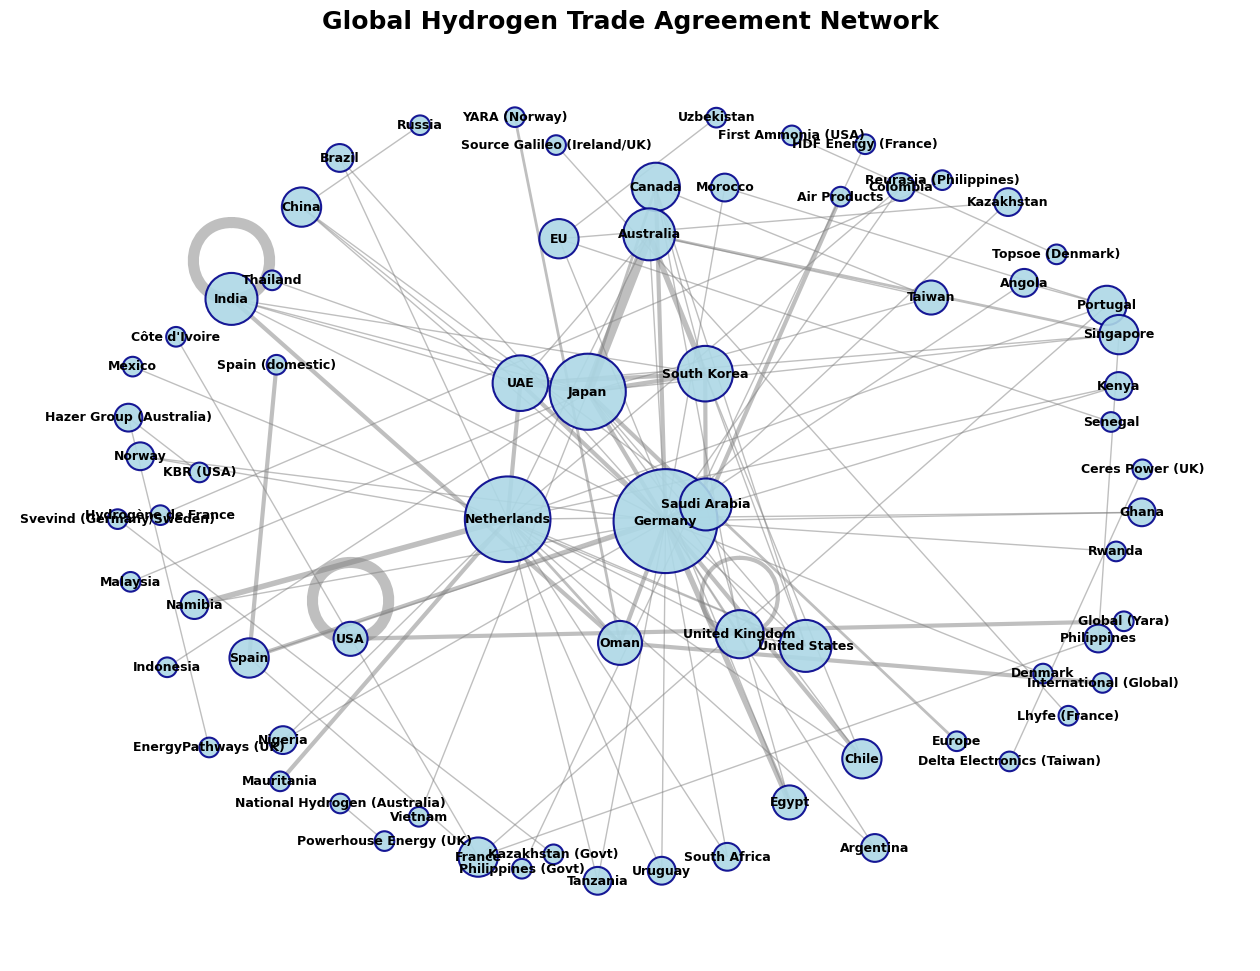


ANALYSIS COMPLETE!

📊 SUMMARY OF FINDINGS:
   • Most connected country (has most partners): Germany
   • Most important bridge (connects regions): Germany
   • Total countries in network: 72
   • Total agreements in network: 113

📅 AGREEMENTS OVER TIME:
   2021: █ 3
   2022: ██████████████ 29
   2023: ███████████████████████████ 55
   2024: ████████ 17
   2025: ████ 9
   2026: ██████ 12


In [72]:
for index, row in df.iterrows():
    # Get the two countries using YOUR column names
    country_a = row['Source Country']
    country_b = row['Target Country']
    
    # Get the weight (agreement importance)
    strength = row['Weight']
    
    # Add or update the connection
    if hydrogen_network.has_edge(country_a, country_b):
        # They already have an agreement - add to the strength
        current = hydrogen_network[country_a][country_b]['weight']
        hydrogen_network[country_a][country_b]['weight'] = current + strength
    else:
        # First agreement between these countries
        hydrogen_network.add_edge(country_a, country_b, weight=strength)
        print(f"✓ Network created!")
print(f"  - Countries in network: {hydrogen_network.number_of_nodes()}")
print(f"  - Agreements between them: {hydrogen_network.number_of_edges()}")
print("\n" + "-" * 60)

# STEP 5: Calculate network statistics
print("NETWORK STATISTICS")
print("-" * 60)

# Density (how connected the network is)
density = nx.density(hydrogen_network)
print(f"Network density: {density:.3f} (0 = no connections, 1 = everyone connected)")

# Average partners per country
total_connections = sum(dict(hydrogen_network.degree()).values())
avg_partners = total_connections / hydrogen_network.number_of_nodes()
print(f"Average partners per country: {avg_partners:.1f}")

print("\n" + "-" * 60)

# STEP 6: Find the most connected countries (Degree Centrality)
print("TOP 10 MOST CONNECTED COUNTRIES (Degree Centrality)")
print("-" * 60)
print("These countries have the most hydrogen trade partners:\n")

degree_centrality = nx.degree_centrality(hydrogen_network)
top_countries = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
for position, (country, score) in enumerate(top_countries, 1):
    percentage = score * 100
    print(f"{position:2}. {country}: {percentage:.0f}% of all possible partners")

print("\n" + "-" * 60)

# STEP 7: Find bridge countries (Betweenness Centrality)
print("TOP 10 MOST IMPORTANT BRIDGE COUNTRIES (Betweenness Centrality)")
print("-" * 60)
print("These countries connect different trading blocs:\n")

betweenness = nx.betweenness_centrality(hydrogen_network)
top_bridges = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]

for position, (country, score) in enumerate(top_bridges, 1):
    print(f"{position:2}. {country}: {score:.3f}")

print("\n" + "-" * 60)

# STEP 8: Draw the network
print("CREATING NETWORK VISUALIZATION...")
print("-" * 60)

# Set up the drawing area
plt.figure(figsize=(16, 12))

# Position the countries on the map
pos = nx.spring_layout(hydrogen_network, k=1.5, iterations=50, seed=42)

# Make country size based on how many partners they have
node_sizes = [hydrogen_network.degree(node) * 200 for node in hydrogen_network.nodes()]

# Make line thickness based on agreement strength
edge_weights = [hydrogen_network[u][v]['weight'] for u, v in hydrogen_network.edges()]

# Draw the countries (circles)
nx.draw_networkx_nodes(
    hydrogen_network, 
    pos, 
    node_size=node_sizes, 
    node_color='lightblue', 
    edgecolors='darkblue', 
    linewidths=1.5,
    alpha=0.9
)

# Draw the agreements (lines between countries)
nx.draw_networkx_edges(
    hydrogen_network, 
    pos, 
    width=edge_weights, 
    alpha=0.5, 
    edge_color='gray'
)

# Draw the country names
nx.draw_networkx_labels(
    hydrogen_network, 
    pos, 
    font_size=9, 
    font_weight='bold'
)

# Add title
plt.title("Global Hydrogen Trade Agreement Network", fontsize=18, fontweight='bold')

# Remove axes (so we just see the network)
plt.axis('off')

# Save the image
plt.savefig('hydrogen_trade_network.png', dpi=300, bbox_inches='tight')
print("✓ Network map saved as 'hydrogen_trade_network.png'")

# Show the image
plt.show()

print("\n" + "=" * 60)
print("ANALYSIS COMPLETE!")
print("=" * 60)

# STEP 9: Summary
top_country = top_countries[0][0]
top_bridge = top_bridges[0][0]

print(f"\n📊 SUMMARY OF FINDINGS:")
print(f"   • Most connected country (has most partners): {top_country}")
print(f"   • Most important bridge (connects regions): {top_bridge}")
print(f"   • Total countries in network: {hydrogen_network.number_of_nodes()}")
print(f"   • Total agreements in network: {hydrogen_network.number_of_edges()}")

# Bonus: Show agreements by year
print("\n📅 AGREEMENTS OVER TIME:")
year_counts = df['Year'].value_counts().sort_index()
for year, count in year_counts.items():
    bar = "█" * (count // 2)
    print(f"   {year}: {bar} {count}")


COMMUNITY DETECTION (Finding Trading Blocs)

✓ Found 15 trading blocs
✓ Average bloc size: 4.8 countries

------------------------------------------------------------
TRADING BLOCS IDENTIFIED
------------------------------------------------------------

Bloc 1: 19 countries
   Countries: Angola, Argentina, Brazil, Colombia, Denmark, Germany, Ghana, Kenya, Mauritania, Morocco, Namibia, Netherlands, Nigeria, Norway, Portugal
   ... and 4 more

Bloc 2: 14 countries
   Countries: Australia, Canada, Chile, India, Indonesia, Japan, Malaysia, Philippines, Singapore, South Korea, Taiwan, Thailand, UAE, Vietnam

Bloc 3: 9 countries
   Countries: Air Products, China, Côte d'Ivoire, Europe, France, Russia, Saudi Arabia, Spain, Spain (domestic)

Bloc 4: 5 countries
   Countries: EU, Egypt, Kazakhstan, Senegal, Uzbekistan

Bloc 5: 3 countries
   Countries: Mexico, United Kingdom, United States

Bloc 6: 3 countries
   Countries: EnergyPathways (UK), Hazer Group (Australia), KBR (USA)

Bloc 7: 3 cou

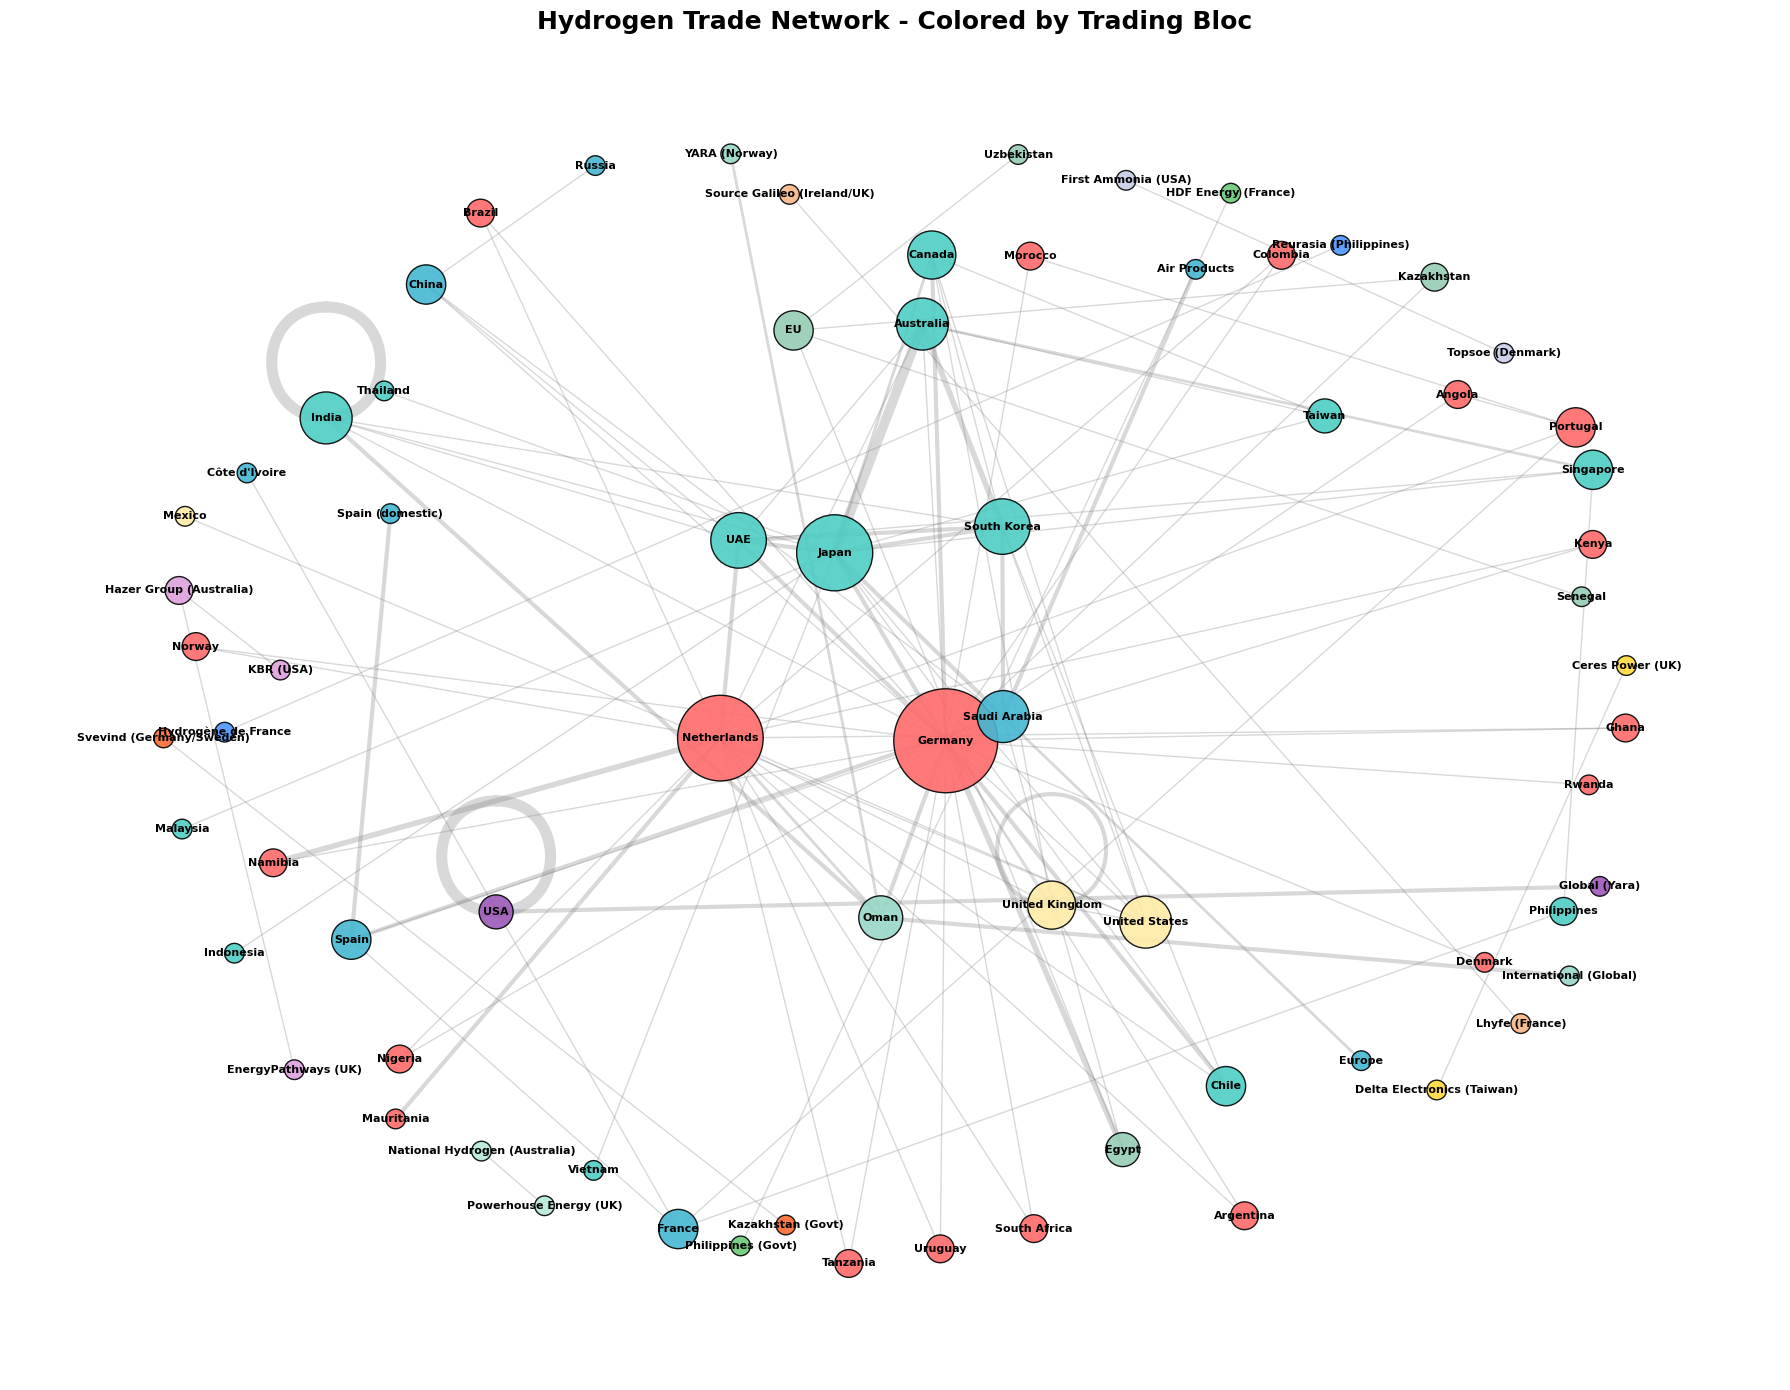

✓ Colored network map saved as 'hydrogen_network_colored.png'

------------------------------------------------------------
TRADING BLOC ANALYSIS
------------------------------------------------------------
Bloc 1: 30 internal agreements, 19 countries
Bloc 2: 25 internal agreements, 14 countries
Bloc 3: 8 internal agreements, 9 countries
Bloc 4: 4 internal agreements, 5 countries
Bloc 5: 3 internal agreements, 3 countries
Bloc 6: 2 internal agreements, 3 countries
Bloc 7: 2 internal agreements, 3 countries
Bloc 8: 1 internal agreements, 2 countries
Bloc 9: 1 internal agreements, 2 countries
Bloc 10: 1 internal agreements, 2 countries
Bloc 11: 1 internal agreements, 2 countries
Bloc 12: 1 internal agreements, 2 countries
Bloc 13: 1 internal agreements, 2 countries
Bloc 14: 1 internal agreements, 2 countries
Bloc 15: 2 internal agreements, 2 countries

✓ Most cohesive trading bloc: Bloc 1 (most internal agreements)


In [82]:
from networkx.algorithms import community


print("\n" + "=" * 60)
print("COMMUNITY DETECTION (Finding Trading Blocs)")
print("=" * 60)

# Run the community detection algorithm
communities = community.greedy_modularity_communities(hydrogen_network)

# Convert communities to a list
community_list = list(communities)

print(f"\n✓ Found {len(community_list)} trading blocs")
print(f"✓ Average bloc size: {sum(len(c) for c in community_list) / len(community_list):.1f} countries")

# STEP 3.2: Show each trading bloc
print("\n" + "-" * 60)
print("TRADING BLOCS IDENTIFIED")
print("-" * 60)

for i, bloc in enumerate(community_list, 1):
    bloc_countries = sorted(list(bloc))
    print(f"\nBloc {i}: {len(bloc_countries)} countries")
    print(f"   Countries: {', '.join(bloc_countries[:15])}")
    if len(bloc_countries) > 15:
        print(f"   ... and {len(bloc_countries) - 15} more")

# STEP 3.3: Color the network by community
print("\n" + "-" * 60)
print("CREATING COLOR-CODED NETWORK MAP")
print("-" * 60)

# Create a color mapping for each community
color_map = {}
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', 
          '#DDA0DD', '#98D8C8', '#F7B787', '#B5EAD7', '#C7CEEA',
          '#FFD93D', '#6BCB77', '#4D96FF', '#FF6B35', '#9B59B6']

for i, bloc in enumerate(community_list):
    for country in bloc:
        color_map[country] = colors[i % len(colors)]

# Draw the colored network
plt.figure(figsize=(18, 14))
pos = nx.spring_layout(hydrogen_network, k=1.5, iterations=50, seed=42)

# Draw nodes with community colors
node_colors = [color_map.get(node, 'lightgray') for node in hydrogen_network.nodes()]
node_sizes = [hydrogen_network.degree(node) * 200 for node in hydrogen_network.nodes()]

nx.draw_networkx_nodes(hydrogen_network, pos, node_size=node_sizes, 
                       node_color=node_colors, alpha=0.9, edgecolors='black', linewidths=1)

nx.draw_networkx_edges(hydrogen_network, pos, width=edge_weights, alpha=0.3, edge_color='gray')
nx.draw_networkx_labels(hydrogen_network, pos, font_size=8, font_weight='bold')

plt.title("Hydrogen Trade Network - Colored by Trading Bloc", fontsize=18, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig('hydrogen_network_colored.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Colored network map saved as 'hydrogen_network_colored.png'")

# STEP 3.4: Bloc analysis
print("\n" + "-" * 60)
print("TRADING BLOC ANALYSIS")
print("-" * 60)

# Find which bloc has the most agreements
bloc_internal_edges = []
for i, bloc in enumerate(community_list):
    internal = hydrogen_network.subgraph(bloc).number_of_edges()
    bloc_internal_edges.append(internal)
    print(f"Bloc {i+1}: {internal} internal agreements, {len(bloc)} countries")

# Find the most cohesive bloc
most_cohesive = bloc_internal_edges.index(max(bloc_internal_edges)) + 1
print(f"\n✓ Most cohesive trading bloc: Bloc {most_cohesive} (most internal agreements)")


STEP 4: CREATING PROFESSIONAL PORTFOLIO VISUALIZATIONS

✓ Creating: Top 10 Hydrogen Powers Bar Chart


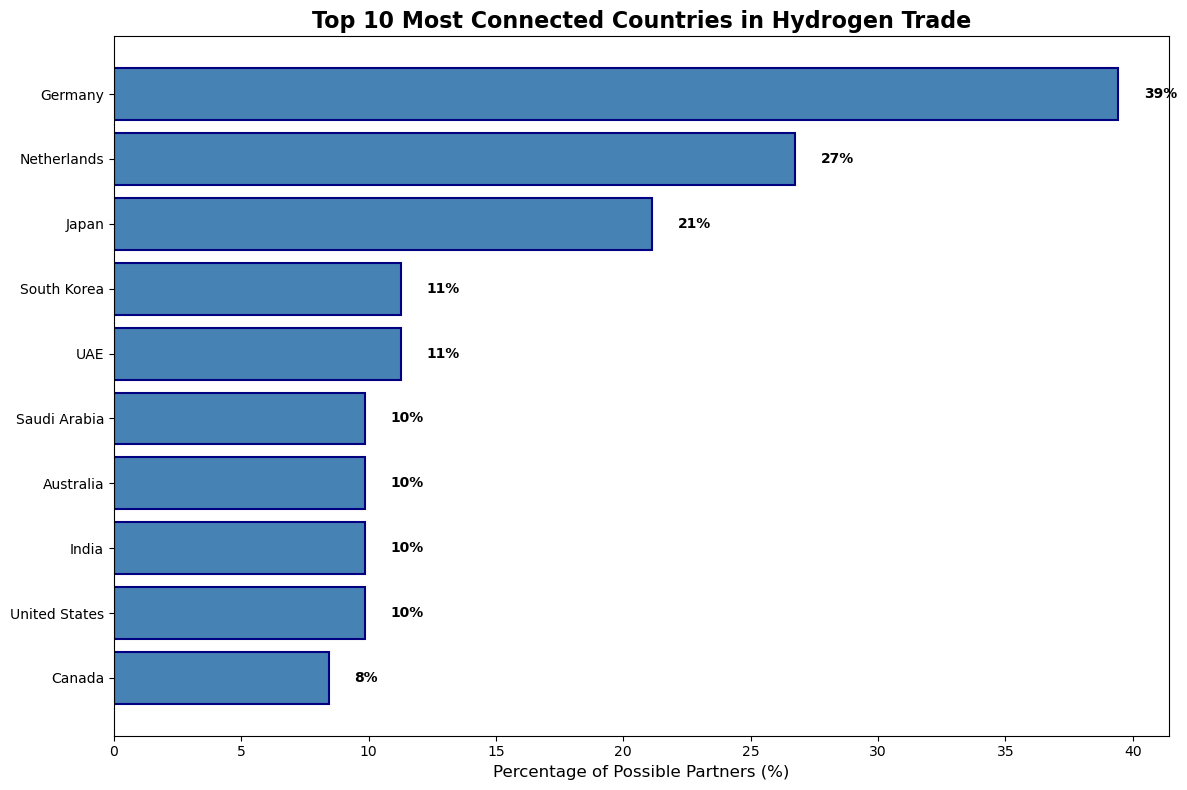


✓ Creating: Hydrogen Agreements Over Time Chart


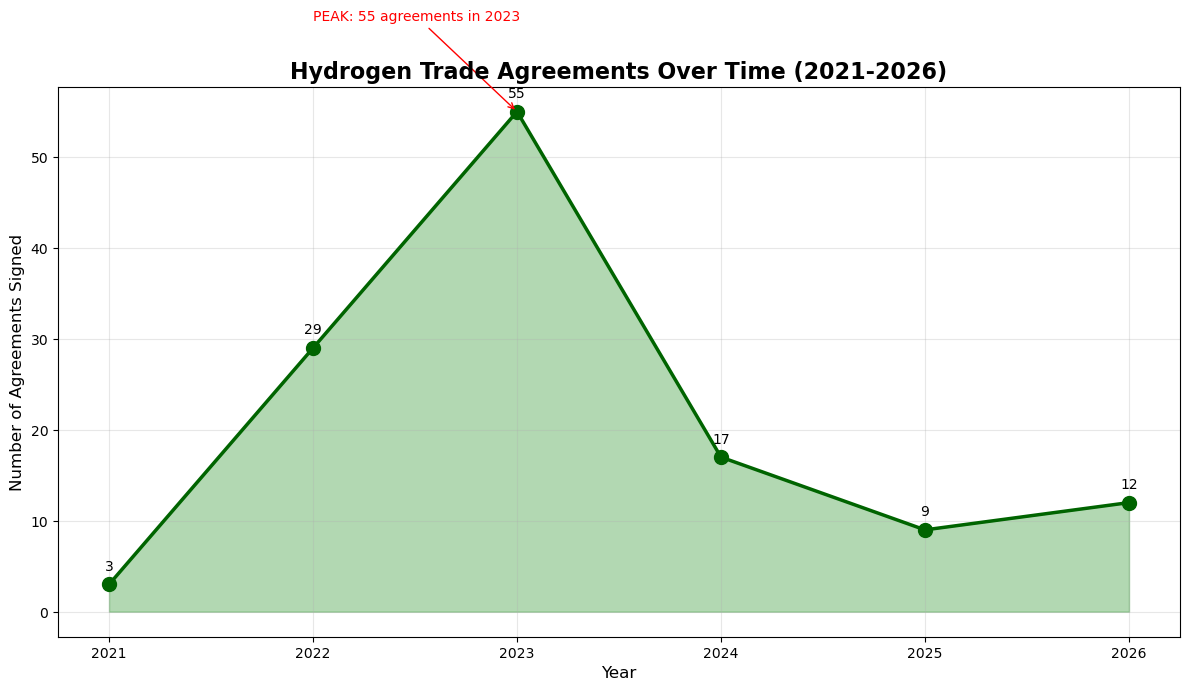


✓ Creating: Trading Bloc Size Distribution Pie Chart


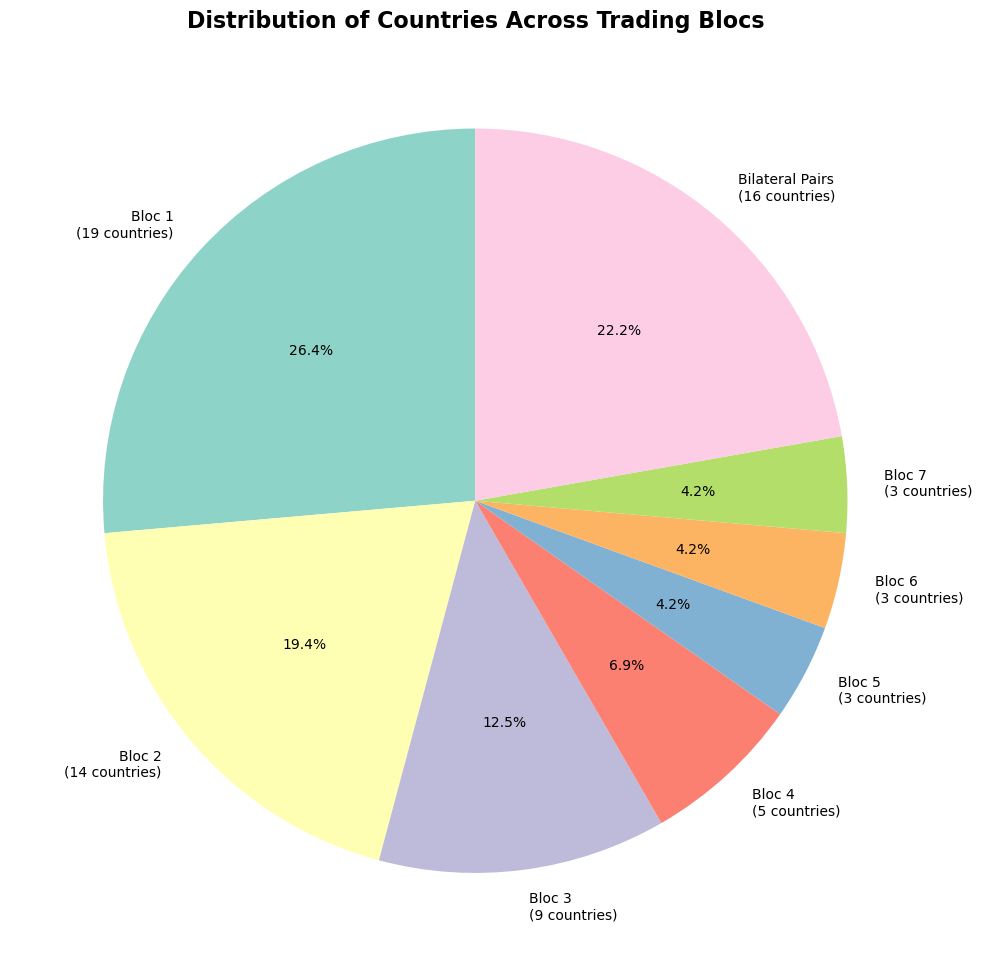


✓ Creating: Enhanced Color-Coded Network Map


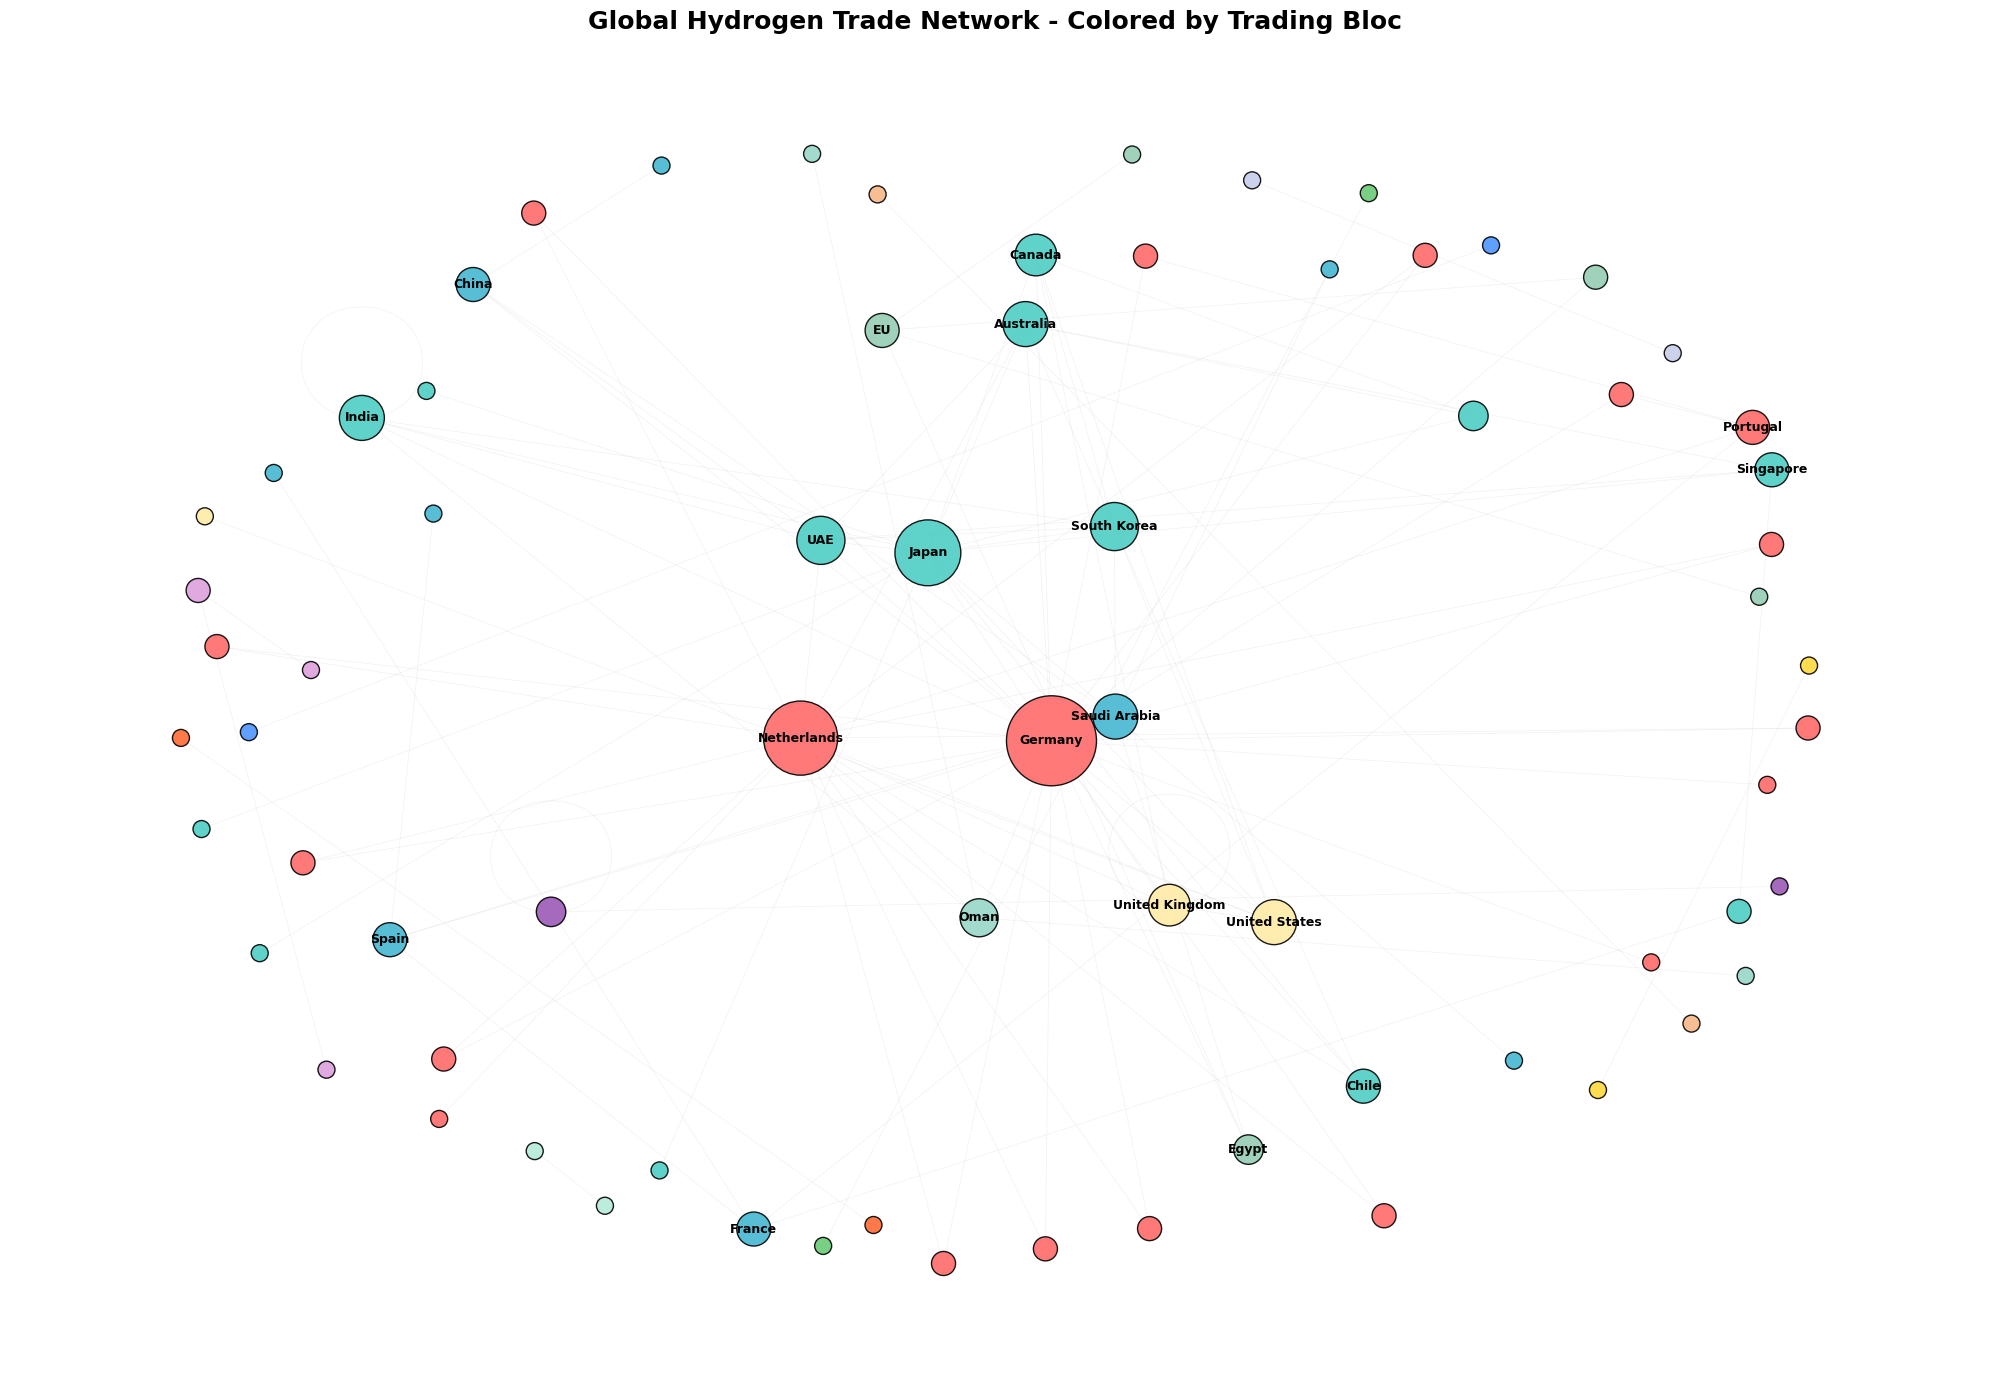

In [80]:
import matplotlib.pyplot as plt
import numpy as np

print("\n" + "=" * 60)
print("STEP 4: CREATING PROFESSIONAL PORTFOLIO VISUALIZATIONS")
print("=" * 60)


print("\n✓ Creating: Top 10 Hydrogen Powers Bar Chart")

top_10_countries = top_countries[:10]
country_names = [c[0] for c in top_10_countries]
country_scores = [c[1] * 100 for c in top_10_countries]

plt.figure(figsize=(12, 8))
bars = plt.barh(country_names, country_scores, color='steelblue', edgecolor='navy', linewidth=1.5)
plt.xlabel('Percentage of Possible Partners (%)', fontsize=12)
plt.title('Top 10 Most Connected Countries in Hydrogen Trade', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()

# Add value labels on bars
for bar, score in zip(bars, country_scores):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f'{score:.0f}%', 
             va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('top_10_hydrogen_powers.png', dpi=300, bbox_inches='tight')
plt.show()


print("\n✓ Creating: Hydrogen Agreements Over Time Chart")

years = sorted(df['Year'].unique())
agreement_counts = [len(df[df['Year'] == year]) for year in years]

plt.figure(figsize=(12, 7))
plt.plot(years, agreement_counts, marker='o', linewidth=2.5, markersize=10, color='darkgreen')
plt.fill_between(years, agreement_counts, alpha=0.3, color='green')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Agreements Signed', fontsize=12)
plt.title('Hydrogen Trade Agreements Over Time (2021-2026)', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)

# Add value labels on points
for year, count in zip(years, agreement_counts):
    plt.annotate(str(count), (year, count), textcoords="offset points", xytext=(0, 10), ha='center')

# Add annotation for the peak
peak_year = years[agreement_counts.index(max(agreement_counts))]
peak_count = max(agreement_counts)
plt.annotate(f'PEAK: {peak_count} agreements in {peak_year}', 
             xy=(peak_year, peak_count), xytext=(peak_year-1, peak_count+10),
             arrowprops=dict(arrowstyle='->', color='red'), fontsize=10, color='red')

plt.tight_layout()
plt.savefig('agreements_over_time.png', dpi=300, bbox_inches='tight')
plt.show()


print("\n✓ Creating: Trading Bloc Size Distribution Pie Chart")

bloc_sizes = [len(bloc) for bloc in community_list]
bloc_labels = [f'Bloc {i+1}\n({size} countries)' for i, size in enumerate(bloc_sizes)]

# Group small blocs (size 2) into "Other Bilateral Partnerships"
large_blocs = []
large_labels = []
other_count = 0

for i, size in enumerate(bloc_sizes):
    if size >= 3:
        large_blocs.append(size)
        large_labels.append(f'Bloc {i+1}\n({size} countries)')
    else:
        other_count += size

if other_count > 0:
    large_blocs.append(other_count)
    large_labels.append(f'Bilateral Pairs\n({other_count} countries)')

plt.figure(figsize=(10, 10))
colors = plt.cm.Set3(range(len(large_blocs)))
plt.pie(large_blocs, labels=large_labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Distribution of Countries Across Trading Blocs', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('trading_bloc_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


print("\n✓ Creating: Enhanced Color-Coded Network Map")

plt.figure(figsize=(20, 14))
pos = nx.spring_layout(hydrogen_network, k=1.5, iterations=50, seed=42)


nx.draw_networkx_edges(hydrogen_network, pos, width=0.5, alpha=0.3, edge_color='lightgray')


node_colors = [color_map.get(node, 'lightgray') for node in hydrogen_network.nodes()]
node_sizes = [hydrogen_network.degree(node) * 150 for node in hydrogen_network.nodes()]

nx.draw_networkx_nodes(hydrogen_network, pos, node_size=node_sizes, 
                       node_color=node_colors, alpha=0.9, edgecolors='black', linewidths=1)


top_20_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:20]
top_20_names = [node for node, score in top_20_degree]

labels = {node: node for node in hydrogen_network.nodes() if node in top_20_names}
nx.draw_networkx_labels(hydrogen_network, pos, labels=labels, font_size=9, font_weight='bold')

plt.title('Global Hydrogen Trade Network - Colored by Trading Bloc', fontsize=18, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig('hydrogen_network_final.png', dpi=300, bbox_inches='tight')
plt.show()




print("\n" + "=" * 60)
print("=" * 60)